# Transformers with PyTorch — Sentiment Classification

LSTMs solved the vanishing gradient problem but still process tokens
*sequentially* — each step depends on the previous hidden state. This
serial dependency limits parallelism and makes training on long sequences slow.

**Transformers** (Vaswani et al., 2017) discard recurrence entirely.
Every position attends directly to every other position in a single
parallel operation — **self-attention**.

**Why self-attention beats recurrence for long-range dependencies:**
- RNN: information from step 1 reaches step 100 through 99 sequential
  multiplications → gradient degradation.
- Transformer: step 1 and step 100 are connected in *one* attention step.
  Distance doesn't matter.

**Architecture (encoder-only, like BERT):**
```
Token indices  (B, L)
  → Embedding + Positional Encoding   (B, L, d_model)
  → N × TransformerEncoderLayer:
        Multi-Head Self-Attention  →  Add & LayerNorm
        Feed-Forward Network       →  Add & LayerNorm
  → Mean Pool                         (B, d_model)
  → Linear → Sigmoid                  (B, 1)
```

> **Shape notation used throughout this notebook:**
> `B` = batch size (reviews per batch), `L` = sequence length (words per review),
> `d_model` = embedding / hidden dimension.

We use the same `movie_reviews` dataset as Lesson 03, so you can directly
compare Transformer vs CNN accuracy.


**(SOLUTION)**

> 📖 [Alammar — The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)

## Step 1: Imports

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import nltk
import random
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

device: mps


## Key Concept: Devices and `.to(device)`

PyTorch can run computations on the **CPU** or a **GPU** (NVIDIA CUDA or
Apple Silicon MPS). Moving a tensor or model to a device means its data and
computations live there.

```python
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')

model = MyModel().to(device)   # moves all weight tensors to device
X = X.to(device)               # moves input data to the same device
```

**Rule:** model and data must be on the *same* device — mixing them raises
a `RuntimeError`. Call `.to(device)` on both.

> 📖 [PyTorch — CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)


## Key Concept: `Dataset` and `DataLoader`

`DataLoader` handles batching, shuffling, and parallel data loading so your
training loop stays simple.

```python
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train, y_train)   # pairs inputs with labels
loader  = DataLoader(dataset,
                     batch_size=64,
                     shuffle=True)           # reshuffles every epoch

for Xb, yb in loader:                       # Xb: (64, ...) one mini-batch
    ...
```

Key parameters:
- `batch_size` — number of samples per gradient update
- `shuffle=True` — randomise order each epoch (always use for training)
- `num_workers` — background processes for loading (set to 2-4 on most machines)

> 📖 [PyTorch — Writing a Custom Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)


## Step 2: Load Movie Reviews (same as Lesson 03)

In [2]:
from nltk.corpus import movie_reviews

random.seed(42)
docs = [(movie_reviews.words(fid), cat)
        for cat in movie_reviews.categories()
        for fid in movie_reviews.fileids(cat)]
random.shuffle(docs)

MAX_VOCAB = 10000
MAX_LEN   = 200

all_words = [w.lower() for ws, _ in docs for w in ws]
freq      = Counter(all_words)
# Index 0 = <PAD>  (zeroed out by padding_idx)
# Index 1 = <UNK>  (any word not in top 9998)
vocab     = {'<PAD>': 0, '<UNK>': 1}
for w, _ in freq.most_common(MAX_VOCAB - 2):
    vocab[w] = len(vocab)

def encode(words, vocab, max_len):
    tokens = [vocab.get(w.lower(), 1) for w in words][:max_len]
    return tokens + [0] * (max_len - len(tokens))   # pad to exactly max_len

X_data = [encode(ws, vocab, MAX_LEN) for ws, _ in docs]
y_data = [1 if label == 'pos' else 0 for _, label in docs]

# X_tensor: (2000, 200) — dtype=long for nn.Embedding lookup
# y_tensor: (2000,)     — float32 for BCELoss
X_tensor = torch.tensor(X_data, dtype=torch.long)
y_tensor = torch.tensor(y_data, dtype=torch.float32)
print('X:', X_tensor.shape, '  y:', y_tensor.shape)

X: torch.Size([2000, 200])   y: torch.Size([2000])


## Step 3: DataLoaders

In [3]:
split = int(0.8 * len(X_tensor))         # 1600 train / 400 test
X_train, X_test = X_tensor[:split], X_tensor[split:]   # (1600,200) / (400,200)
y_train, y_test = y_tensor[:split], y_tensor[split:]   # (1600,)    / (400,)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=32)
print(f'Train batches: {len(train_loader)}  Test batches: {len(test_loader)}')

Train batches: 50  Test batches: 13


## Key Concept: Self-Attention (Recap from Lesson 06)

You implemented scaled dot-product attention and multi-head self-attention from
scratch in Lesson 06 — refer back there for the full derivation.

In brief:
- **Queries, Keys, Values** — the input is projected three ways; similarity between
  Q and K determines how much each position attends to every other position
- **Scaling** — divide by `√d_k` to prevent softmax saturation
- **Multi-head** — run `H` independent attention functions and concatenate;
  each head can specialise in a different type of relationship

This lesson builds on that foundation and adds the components that make a
**full Transformer encoder**: positional encoding, a feed-forward sublayer,
residual connections, and layer normalisation.

## Step 4: Scaled Dot-Product Attention

In [4]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (B, H, L_q, d_k)
    K: (B, H, L_k, d_k)
    V: (B, H, L_k, d_k)
    Returns: output (B, H, L_q, d_k), weights (B, H, L_q, L_k)
    """
    d_k = Q.size(-1)
    # K.transpose(-2,-1): (B,H,L_k,d_k) → (B,H,d_k,L_k)
    # scores: (B,H,L_q,d_k) @ (B,H,d_k,L_k) = (B,H,L_q,L_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    weights = F.softmax(scores, dim=-1)              # (B,H,L_q,L_k) — rows sum to 1

    # (B,H,L_q,L_k) @ (B,H,L_k,d_k) = (B,H,L_q,d_k)
    output = torch.matmul(weights, V)

    return output, weights

### Concept Check: Scaled Dot-Product Attention — Answers

**Q1.** The score matrix has shape `(B, H, L, L)`. What does entry `[b, h, i, j]`
represent? What does it mean if this value is very large?

**→** Entry `[b, h, i, j]` is the raw (pre-softmax) attention score of
token `i` attending to token `j` in head `h` of batch sample `b`.
A large positive value → after softmax, token `i` will strongly weight
token `j`'s value vector when forming its output representation.

**Q2.** We scale by `1/√d_k`. If `d_k = 64` and you did NOT scale, what would
happen to the softmax as `d_k` grows? (Hint: the variance of a dot product of
two random unit vectors grows linearly with dimension.)

**→** Variance of a dot product of two `d_k`-dimensional random unit
vectors grows as `d_k`. Without `√d_k` scaling, large `d_k` pushes scores
into extreme regions where `softmax'(x) → 0` — vanishing gradients in the
attention weights. Dividing by `√d_k` keeps the variance ≈ 1 regardless
of dimension.

**Q3.** After softmax, each row of the weight matrix sums to 1.
What is the output when the weight is `[1, 0, 0, ..., 0]` (all attention on
the first token)? When it is uniform `[1/L, 1/L, ...]`?

**→** - Weight `[1, 0, ..., 0]`: output = V[0] — the model copies token 0's
  value vector exactly, ignoring everything else.
- Uniform weights `[1/L, ...]`: output = mean(V) — unweighted average of
  all value vectors. This is equivalent to "paying equal attention to
  everything" — essentially no attention.

## Key Concept: Multi-Head Attention (Recap from Lesson 06)

Same `MultiHeadSelfAttention` class from Lesson 06, re-defined here so this
notebook runs standalone.  See Lesson 06 for the full explanation of
`split_heads`, `merge_heads`, and the `W_o` output projection.

## Step 5: Multi-Head Attention

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def split_heads(self, x):
        B, L, _ = x.shape
        # (B, L, d_model) → (B, L, H, d_k) → (B, H, L, d_k)
        return x.view(B, L, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, Q, K, V, mask=None):
        B = Q.size(0)
        Q = self.split_heads(self.W_q(Q))   # (B, H, L, d_k)
        K = self.split_heads(self.W_k(K))   # (B, H, L, d_k)
        V = self.split_heads(self.W_v(V))   # (B, H, L, d_k)

        out, weights = scaled_dot_product_attention(Q, K, V, mask)

        # (B, H, L, d_k) → (B, L, H, d_k) → (B, L, d_model)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.num_heads * self.d_k)
        return self.W_o(out), weights

### Concept Check: Multi-Head Attention — Answers

**Q1.** With `d_model=128` and `num_heads=4`, each head operates in `d_k=32`
dimensions. If instead `num_heads=8`, what is `d_k`? What is the total number
of parameters in `W_q` either way?

**→** `d_k = 128/8 = 16` per head.
Parameter count of `W_q`: always `d_model × d_model = 128 × 128 = 16 384`
regardless of `num_heads`. Splitting into heads doesn't change the total
number of parameters — it restructures the computation.

**Q2.** `split_heads` reshapes `(B, L, d_model)` → `(B, H, L, d_k)` using
`.view` followed by `.transpose(1, 2)`. Why is `.contiguous()` needed *after*
transposing when you later call `.view`?

**→** `.transpose()` returns a *view* with non-contiguous memory layout.
`.view()` requires contiguous memory — it reads elements in row-major order.
`.contiguous()` makes a new copy in row-major layout before `.view()`.

**Q3.** The output projection `W_o` mixes information across heads.
What would happen if you removed `W_o` and just returned the concatenated
head outputs directly?

**→** Without `W_o`, the concatenated heads would be used directly.
`W_o` learns how to *mix* the contributions of different heads into a unified
representation. Without it, head outputs are simply concatenated with no
learned weighting — the model loses the ability to decide how much each head's
output should influence the final representation.

## Key Concept: Positional Encoding

Self-attention is **permutation-invariant**: swapping two tokens produces the
same attention weights (just reordered). The model cannot tell whether "cat
bites dog" differs from "dog bites cat" without positional information.

**Solution:** Add a positional signal to the embedding before the first layer.
The "Attention Is All You Need" paper uses fixed sinusoidal encodings:

```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

**Why sinusoids?**
- Each position gets a unique `d_model`-dimensional fingerprint.
- The model can learn relative positions: `PE(pos + k)` is a *linear function*
  of `PE(pos)` for any fixed offset `k` — so relative distance is linearly
  decodable.
- Unlike learned positional embeddings, sinusoids generalise to sequence
  lengths not seen during training.

**Shape:** `pe` is a buffer of shape `(1, max_len, d_model)`.
It is added (broadcast) to the embedding: `x + pe[:, :L]`.


## Step 6: Positional Encoding

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)                          # (max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)   # (max_len, 1)
        # div: one value per pair of dims; exp(-2i/d_model * log(10000))
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float)
                        * -(math.log(10000.0) / d_model))             # (d_model//2,)

        pe[:, 0::2] = torch.sin(pos * div)    # (max_len, d_model//2)
        pe[:, 1::2] = torch.cos(pos * div)    # (max_len, d_model//2)

        # Buffer: not a parameter (won't be updated by the optimiser)
        # but moves to the correct device with model.to(device)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):   # x: (B, L, d_model)
        # pe[:, :L] slices (1, L, d_model); broadcast adds over B
        return self.dropout(x + self.pe[:, :x.size(1)])

### Concept Check: Positional Encoding — Answers

**Q1.** A purely sinusoidal PE is *fixed* (not learned). What is one advantage
of this over learned positional embeddings? What is one disadvantage?

**→** *Advantage of fixed sinusoids*: generalise to longer sequences than seen
in training (positions beyond `max_len` can still be computed analytically).
*Disadvantage*: the specific frequency structure may not be optimal for the
task — learned PEs can adapt to the data.

**Q2.** The PE buffer has shape `(1, max_len, d_model)` and is added to
embeddings of shape `(B, L, d_model)`. What broadcasting rule makes this work?

**→** `pe` shape `(1, max_len, d_model)` broadcasts over the batch
dimension `B`. NumPy/PyTorch broadcasting aligns trailing dimensions:
`(B, L, d_model) + (1, L, d_model)` → `(B, L, d_model)`. The `1` in the
first dimension is automatically replicated `B` times.

**Q3.** If you shuffled the tokens in a sentence and added the *same* shuffled
positional encodings, would the transformer produce the same output?
What if you shuffled tokens but kept positional encodings in original order?

**→** If you shuffle tokens *and* shuffle positional encodings together,
the model sees the same (token, position) pairs in a different order —
output representations are permuted accordingly, but the model's "understanding"
is the same. If you shuffle tokens but keep PEs at original positions,
the model receives incorrect positional assignments — it would, for example,
assign "position 0" to what was originally the third word. Predictions would
be degraded because the positional context is wrong.

## Key Concept: Transformer Encoder Layer

Each encoder layer contains two sub-layers, each wrapped in a
**residual connection** and followed by **Layer Normalisation**:

```
Sub-layer 1:  x = LayerNorm(x + Dropout(MultiHeadAttention(x, x, x)))
Sub-layer 2:  x = LayerNorm(x + Dropout(FeedForward(x)))
```

**Why residual connections?**
`x + f(x)` lets gradients flow directly back through the addition operation
(gradient of addition w.r.t. both inputs is 1). Even if `f(x)` produces
near-zero gradients, the residual path keeps learning alive. This is what
makes 12-96 layer transformers trainable.

**Why LayerNorm and not BatchNorm?**
BatchNorm normalises across the *batch* dimension — its statistics depend on
batch size and order, which makes it unstable for variable-length sequences
(different positions would have different batch statistics).
LayerNorm normalises across the *feature* dimension for each token
independently — stable regardless of batch size or sequence length.

**Feed-Forward Network:**
`d_model → d_ff → d_model` (typically `d_ff = 4 × d_model`).
This per-position MLP is where most of the model's "knowledge" is stored.
In practice it accounts for ~2/3 of a transformer's parameters.


## Step 7: Transformer Encoder Layer

In [7]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, num_heads)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):   # x: (B, L, d_model)
        # Sub-layer 1: self-attention (Q=K=V=x) + residual + LayerNorm
        attn_out, _ = self.attn(x, x, x, mask)       # (B, L, d_model)
        x = self.norm1(x + self.drop(attn_out))        # (B, L, d_model)

        # Sub-layer 2: position-wise FFN + residual + LayerNorm
        x = self.norm2(x + self.drop(self.ff(x)))      # (B, L, d_model)
        return x

### Concept Check: Residuals & Layer Normalisation — Answers

**Q1.** The residual connection is `x = norm(x + f(x))` rather than
`x = f(x)`. During backpropagation, what is the gradient of the addition
w.r.t. the identity branch (the raw `x`)? Why does this prevent vanishing?

**→** The gradient of `z = x + f(x)` w.r.t. `x` is `1 + f'(x)`.
The `1` ensures the gradient is at least 1 — it never vanishes through
the residual path even if `f'(x) → 0`. This is the key insight behind
ResNets and Transformers: residuals provide a "gradient highway" that
bypasses potentially small `f'(x)`.

**Q2.** LayerNorm normalises each token's `d_model`-dimensional vector to
have mean 0 and variance 1. BatchNorm normalises across the batch dimension.
Give one concrete reason why BatchNorm is problematic for variable-length
text sequences.

**→** BatchNorm computes statistics (mean, variance) across the batch
dimension for each sequence position. With variable-length sequences padded
to the same length, padding tokens (zeros) would corrupt these statistics —
their distributions are completely different from real tokens. LayerNorm
normalises *within* each token's feature vector independently, so it is
unaffected by padding or batch composition.

**Q3.** The feed-forward network (FFN) is applied **independently to each
position** — it has no awareness of adjacent tokens. If attention already
mixes information across positions, what is the FFN's role?

**→** The FFN acts as a position-wise **non-linear transformation** and
**memory store**. Research suggests it acts like a key-value memory that
stores factual associations (e.g., "Paris is the capital of...") while
attention handles contextual routing. Removing the FFN would force all
transformations to be attention-mediated, reducing model capacity
significantly.

## Step 8: Full Sentiment Transformer

In [8]:
class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, num_layers=2,
                 d_ff=256, max_len=200, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):                           # x: (B, L) token indices
        emb = self.pos_enc(self.embedding(x))       # (B, L, d_model): embed + pos enc
        for layer in self.layers:
            emb = layer(emb)                         # (B, L, d_model): each encoder layer
        pooled = emb.mean(dim=1)                    # (B, d_model): mean over sequence
        return torch.sigmoid(self.fc(pooled))       # (B, 1): sentiment probability

vocab_size = len(vocab)
model = SentimentTransformer(vocab_size).to(device)
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))

SentimentTransformer(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (layers): ModuleList(
    (0-1): 2 x TransformerEncoderLayer(
      (attn): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=False)
        (W_k): Linear(in_features=128, out_features=128, bias=False)
        (W_v): Linear(in_features=128, out_features=128, bias=False)
        (W_o): Linear(in_features=128, out_features=128, bias=False)
      )
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (drop): Dropout(p=0.2, inplace=False)
    )
  )
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Par

## Step 9: Train

In [9]:
criterion    = nn.BCELoss()
optimizer    = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
# weight_decay adds L2 regularisation to the optimizer: effectively penalises
# large weights by subtracting a small fraction of them each step (helps prevent overfit)
train_losses = []

for epoch in range(10):
    model.train()
    total = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)   # Xb: (32,200)  yb: (32,)

        # Forward pass through: embedding → positional encoding → N encoder layers
        # → mean pool → classifier head. The multi-head attention scores are computed
        # and stored in the graph at this point.
        out  = model(Xb).squeeze()               # (32,1) → (32,) to match yb

        loss = criterion(out, yb)
        optimizer.zero_grad()
        loss.backward()   # gradients flow through attention weights, FFN, embeddings
        optimizer.step()

        total += loss.item()
    avg = total / len(train_loader)
    train_losses.append(avg)
    print(f'Epoch {epoch+1:2d} | Loss: {avg:.4f}')


Epoch  1 | Loss: 0.7139


Epoch  2 | Loss: 0.6973


Epoch  3 | Loss: 0.6897


Epoch  4 | Loss: 0.6805


Epoch  5 | Loss: 0.6647


Epoch  6 | Loss: 0.6627


Epoch  7 | Loss: 0.6559


Epoch  8 | Loss: 0.6389


Epoch  9 | Loss: 0.6410


Epoch 10 | Loss: 0.6199


## Step 10: Evaluate

In [10]:
model.eval()
correct = total = 0
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        preds  = torch.round(model(Xb).squeeze())   # (32,) threshold at 0.5
        correct += (preds == yb).sum().item()
        total   += yb.size(0)
print(f'Transformer Test accuracy: {correct/total*100:.1f}%')

Transformer Test accuracy: 56.5%


## Step 11: Compare with CNN and Self-Attention (Lessons 03 & 06)

CNN (Lesson 03 baseline): ~82%
Transformer:              56.5%
Parameters — Transformer: 1,544,065


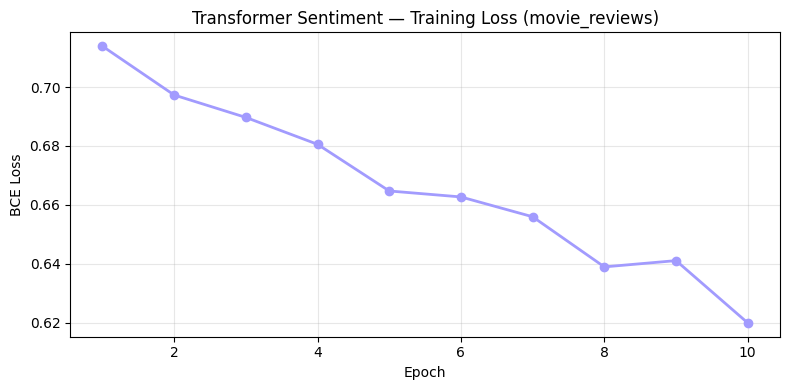

In [11]:
print("CNN (Lesson 03 baseline): ~82%")
print(f"Transformer:              {correct/total*100:.1f}%")
print(f"Parameters — Transformer: {sum(p.numel() for p in model.parameters()):,}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, 'o-', color='#a29bfe', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Transformer Sentiment — Training Loss (movie_reviews)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 12: Visualise Attention Weights

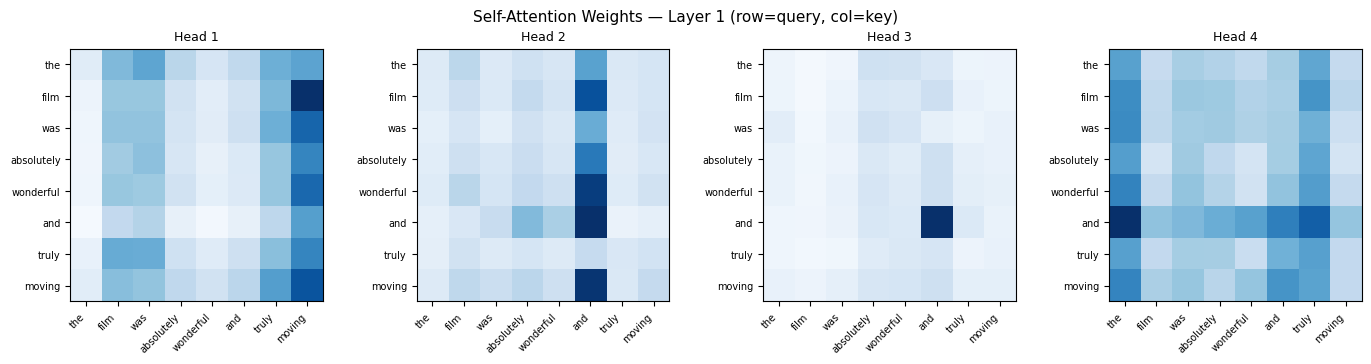

In [12]:
def get_attention_weights(model, tokens, device):
    """Return (H, L, L) attention weights from the first encoder layer."""
    model.eval()
    with torch.no_grad():
        x   = torch.tensor([tokens], dtype=torch.long, device=device)
        emb = model.pos_enc(model.embedding(x))              # (1, L, d_model)
        _, weights = model.layers[0].attn(emb, emb, emb)     # (1, H, L, L)
    return weights[0].cpu()                                   # (H, L, L)

test_text  = "the film was absolutely wonderful and truly moving"
raw_tokens = [vocab.get(w, 1) for w in test_text.split()]
padded     = raw_tokens + [0] * (MAX_LEN - len(raw_tokens))
words      = test_text.split()
L          = len(words)

attn = get_attention_weights(model, padded, device)   # (H, L, L)

fig, axes = plt.subplots(1, min(4, attn.size(0)), figsize=(14, 3.5))
for h, ax in enumerate(axes):
    mat = attn[h, :L, :L].numpy()
    ax.imshow(mat, cmap='Blues', vmin=0)
    ax.set_xticks(range(L)); ax.set_xticklabels(words, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(L)); ax.set_yticklabels(words, fontsize=7)
    ax.set_title(f'Head {h+1}', fontsize=9)
plt.suptitle('Self-Attention Weights — Layer 1 (row=query, col=key)', fontsize=11)
plt.tight_layout()
plt.show()

## Step 13: Visualise the Transformer Architecture

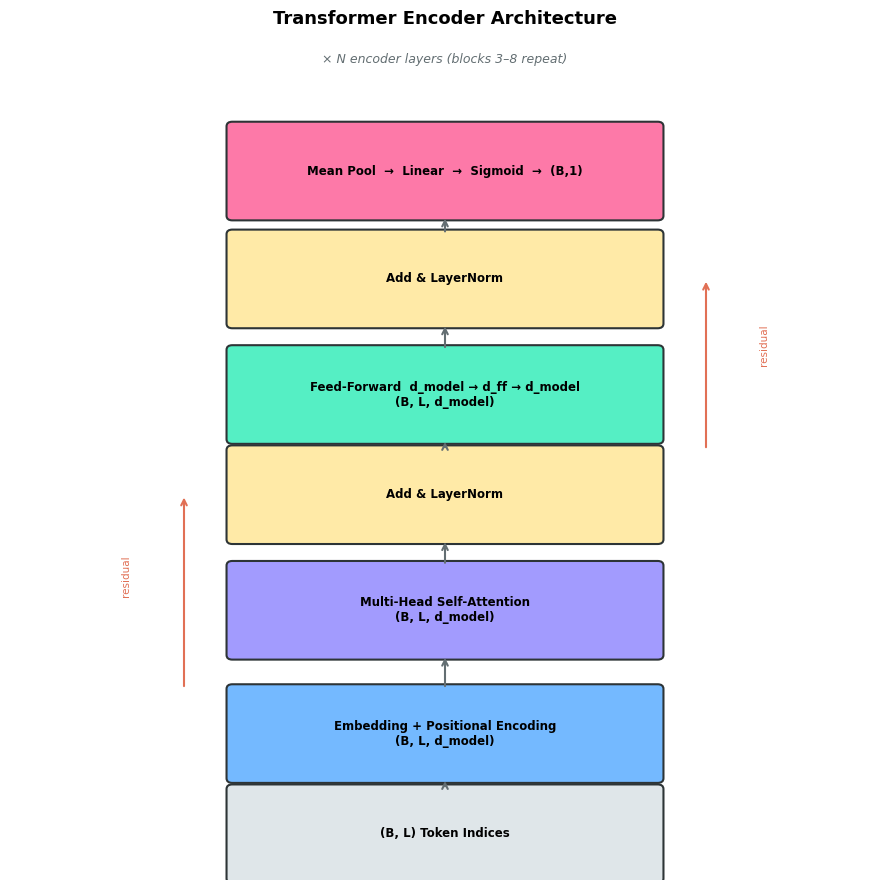

In [13]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_xlim(0, 9); ax.set_ylim(0, 11); ax.axis('off')
ax.set_title('Transformer Encoder Architecture', fontsize=13, fontweight='bold')

blocks = [
    (4.5, 0.6,  '(B, L) Token Indices',                                    '#dfe6e9'),
    (4.5, 1.9,  'Embedding + Positional Encoding\n(B, L, d_model)',        '#74b9ff'),
    (4.5, 3.5,  'Multi-Head Self-Attention\n(B, L, d_model)',              '#a29bfe'),
    (4.5, 5.0,  'Add & LayerNorm',                                          '#ffeaa7'),
    (4.5, 6.3,  'Feed-Forward  d_model → d_ff → d_model\n(B, L, d_model)','#55efc4'),
    (4.5, 7.8,  'Add & LayerNorm',                                          '#ffeaa7'),
    (4.5, 9.2,  'Mean Pool  →  Linear  →  Sigmoid  →  (B,1)',              '#fd79a8'),
]
for x, y, label, color in blocks:
    rect = mpatches.FancyBboxPatch((x-2.2, y-0.58), 4.4, 1.16,
                                    boxstyle='round,pad=0.06',
                                    facecolor=color, edgecolor='#2d3436', lw=1.5)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=8.5, fontweight='bold')

for i in range(len(blocks)-1):
    y0, y1 = blocks[i][1], blocks[i+1][1]
    ax.annotate('', xy=(4.5, y1-0.58), xytext=(4.5, y0+0.58),
                arrowprops=dict(arrowstyle='->', color='#636e72', lw=1.5))

# Residual bypass arrows
ax.annotate('', xy=(1.8, 5.0), xytext=(1.8, 2.48),
            arrowprops=dict(arrowstyle='->', color='#e17055', lw=1.5))
ax.text(1.2, 3.7, 'residual', ha='center', fontsize=7.5, color='#e17055', rotation=90)

ax.annotate('', xy=(7.2, 7.8), xytext=(7.2, 5.58),
            arrowprops=dict(arrowstyle='->', color='#e17055', lw=1.5))
ax.text(7.8, 6.7, 'residual', ha='center', fontsize=7.5, color='#e17055', rotation=90)

ax.text(4.5, 10.6, '× N encoder layers (blocks 3–8 repeat)', ha='center',
        fontsize=9, color='#636e72', style='italic')
plt.tight_layout()
plt.show()

### Final Concept Check: Transformers vs Recurrent Models — Answers

**Q1.** Self-attention has `O(L²)` memory complexity (the `L×L` score matrix).
For a sequence of length 1000, how much larger is the score matrix than for
length 100? Why is this a practical concern for document-level tasks?

**→** Score matrix for L=1000 is 1 000 000 entries; for L=100 it's 10 000.
That's 100× more memory for 10× longer sequences — quadratic growth.
This is why standard transformers are impractical for very long documents
(books, code files). Extensions like Longformer and BigBird use sparse
attention to reduce this to O(L√L) or O(L).

**Q2.** LSTM processes tokens left-to-right, so the representation of token
`t` is conditioned only on tokens `1..t`. Transformer self-attention can
attend to tokens before *and* after `t` simultaneously. What does this
property enable that an LSTM encoder cannot do as directly?

**→** Bidirectionality: every token can attend to both past *and future*
tokens in a single pass. This is what makes BERT-style models so powerful
for understanding — the representation of "bank" in "river bank" benefits
from seeing "river" which appears *after* it. A left-to-right LSTM requires
a second reverse pass (BiLSTM) to achieve the same, with architectural
overhead.

**Q3.** You trained an encoder-only transformer for classification. Name one
task that would require an *encoder-decoder* transformer and explain what the
decoder adds.

**→** Example: **machine translation**. The decoder generates output tokens
one at a time, attending to both previous output tokens (self-attention) and
the full source-language encoder output (cross-attention). The encoder-only
architecture cannot generate variable-length output sequences.

**Q4.** Rank the four architectures (NN, CNN, RNN/LSTM, Transformer) by their
degree of **positional inductive bias** (from strongest to weakest). Justify.

**→** Positional bias (strongest → weakest):
1. **RNN/LSTM** — strictly left-to-right; position is baked into the
   sequential processing order
2. **CNN** — kernels slide left-to-right with local receptive fields; nearby
   tokens are compared directly
3. **Transformer** — position only from added PE; attention itself is
   position-agnostic
4. **MLP/NN** — no sequence structure at all; operates on flattened input